# Compare CVE -> CWE methods

We compare the methods that predict the CWE(s) for a CVE description:

| Method | Model | How it predicts |
| --- | --- | --- |
| **Baseline** | `sentence-transformers/all-MiniLM-L6-v2` | CWE embeddings, two-stage (category -> child) + flat, no fine-tuning |
| **A: hier full** | local `merged_A_hier_full` | CWE embeddings, two-stage (category -> child) + flat |
| **B: children only** | local `merged_B_children_only` | CWE embeddings, flat child search (and the same hierarchy) |
| **SOTA** | `mulliken/cwe-predictor` | a pre-trained classifier over a fixed label set (flat only) |

All methods are scored with the same metric, **Recall@k** (a hit if any ground-truth id is in the top-k), for three targets:

- **Category** recall,
- **Hierarchical child** recall (category beam -> its children),
- **Flat child** recall.

Plotting all of these together is 9+ overlapping lines, which is unreadable. Instead this notebook uses
**small multiples** (one panel per target, one line per method) plus a **summary table** and a
**grouped bar chart** at a chosen k.

> `merged_*` checkpoints are loaded from this `experiments/` folder when running locally. In Colab upload
> them next to the notebook (e.g. `/content/merged_A_hier_full`) and update `ST_METHODS` below.


### Requirements

In [3]:
# %pip install torch --index-url https://download.pytorch.org/whl/cpu
%pip install torch sentence-transformers transformers pandas numpy networkx tqdm matplotlib huggingface_hub

## Setup

In [1]:
import ast
import json
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# == KAGGLE/COLAB ==
# !git clone https://github.com/regularpooria/CWE_CVE_Mapping
# BASE_DIR = "./CWE_CVE_Mapping"

# == LOCAL ==
BASE_DIR = "../"

HF_CVE_REPO_ID = "regularpooria/NVD_CVE_699_Dataset"  # pushed by dataset/push_nvd_to_huggingface.ipynb
SOTA_MODEL_ID = "mulliken/cwe-predictor"              # state-of-the-art flat classifier

KS = [1, 2, 3, 5, 10]
BEAM = 3  # categories visited by the hierarchical search

# Set to an int (e.g. 5000) for a quick run, or None to use every CVE.
SAMPLE_SIZE = None

# Sentence-transformer methods to compare. The baseline is the stock model;
# the two fine-tuned checkpoints live in `merged_*`.
ST_METHODS = {
    "Baseline (MiniLM)": "sentence-transformers/all-MiniLM-L6-v2",
    "A: hier full": "./merged_A_hier_full",
    "B: children only": "./merged_B_children_only",
}

/home/regularpooria/Projects/CWE_CVE_Mapping/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1005 21:29:23.800000 1422899 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1005 21:29:23.859000 1422899 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


In [4]:
!tar -xf merged_.tar.gz

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: merged_B_children_only/config_sentence_transformers.json: time stamp 2026-10-06 02:48:08 is 6210.1370844 s in the future
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: merged_B_children_only/README.md: time stamp 2026-10-06 02:48:08 is 6210.136880857 s in the future
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: merged_B_children_only/tokenizer_config.json: time stamp 2026-10-06 02:48:08 is 6210.136754896 s in the future
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: merged_B_children_only/tokenizer.json: time stamp 2026-10-06 02:48:08 is 6210.131469819 s in the future
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: merged_B_children_only/sentence_bert_config.json

## Load the CWE hierarchy and the CVE data

The CVE rows (with their `true_children` / `true_categories` ground truth) come from the published
Hugging Face dataset. `CWE_SOFTWARE.json` is still read locally for the CWE hierarchy used to embed
and search over categories/children.

In [7]:
!wget https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
with open(f"CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

CVE = pd.read_csv(f"hf://datasets/{HF_CVE_REPO_ID}/NVD_CVE_Dataset.csv")
CVE["true_children"] = CVE["true_children"].apply(ast.literal_eval)
CVE["true_categories"] = CVE["true_categories"].apply(ast.literal_eval)

if SAMPLE_SIZE:
    CVE = CVE.sample(SAMPLE_SIZE, random_state=0).reset_index(drop=True)

if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")
if (CVE["true_children"].str.len() == 0).any():
    raise ValueError("Some CVEs have no known CWE-699 child")

print(f"{len(CVE):,} CVEs loaded")

--2026-10-06 01:05:15--  https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330024 (322K) [text/plain]
Saving to: ‘CWE_SOFTWARE.json’

CWE_SOFTWARE.json   100%[===================>] 322.29K  --.-KB/s    in 0.02s   

2026-10-06 01:05:16 (13.2 MB/s) - ‘CWE_SOFTWARE.json’ saved [330024/330024]

88,146 CVEs loaded


## CWE graph (root -> category -> child)

In [8]:
def make_graph(CWE):
    G = nx.DiGraph()
    G.add_node("root", type="main")
    for cat_id, category in CWE.items():
        G.add_node(cat_id, type="category", title=category["title"])
        G.add_edge("root", cat_id)
        for child_id, child in category["children"].items():
            if not G.has_node(child_id):  # a child can belong to several categories
                G.add_node(child_id, type="child", title=child["title"])
            G.add_edge(cat_id, child_id)
    return G


graph = make_graph(CWE)

category_ids = list(CWE.keys())
child_ids = [n for n, d in graph.nodes(data=True) if d["type"] == "child"]
child_pos = {cid: i for i, cid in enumerate(child_ids)}

# children (as row indices into the child matrix) for every category
category_child_rows = [
    [child_pos[c] for c in graph.successors(cat_id)] for cat_id in category_ids
]

# child id -> parent category ids (used to turn SOTA's ranked children into categories)
child_to_cats = {}
for cat_id, category in CWE.items():
    for child_id in category["children"].keys():
        child_to_cats.setdefault(child_id, []).append(cat_id)

print(f"{len(category_ids)} categories, {len(child_ids)} children")

40 categories, 399 children


## Metrics and shared helpers

In [9]:
def recall_at_k(truths, predictions, k):
    """Hit if ANY true id is in the top-k predictions."""
    return float(np.mean([bool(set(t) & set(p[:k])) for t, p in zip(truths, predictions)]))


def mean_reciprocal_rank(truths, predictions):
    """Mean of 1 / rank of the first correct prediction (0 if none)."""
    ranks = []
    for t, p in zip(truths, predictions):
        t = set(t)
        rank = next((i for i, pred in enumerate(p, start=1) if pred in t), None)
        ranks.append(1.0 / rank if rank else 0.0)
    return float(np.mean(ranks))


def curves(truths, predictions):
    """Recall@k for every k in KS."""
    return {k: recall_at_k(truths, predictions, k) for k in KS}


def extract_description(child):
    description = child["description"]
    if child["extended_description"] is not None:
        description += f"\n{child['extended_description']}"
    return description


def build_cwe_embeddings(model):
    """Embed every CWE child and category once for one sentence-transformer."""
    child_lookup = {}
    for category in CWE.values():
        for child_id, child in category["children"].items():
            child_lookup.setdefault(child_id, child)

    child_embeddings = model.encode(
        [extract_description(child_lookup[cid]) for cid in child_ids],
        batch_size=64, show_progress_bar=True, convert_to_tensor=True,
    )

    category_embeddings = []
    for cat_id in tqdm(category_ids):
        category = CWE[cat_id]
        child_titles = [child["title"] for child in category["children"].values()]
        text = category["title"] + ",".join(child_titles) + category["summary"]
        category_embeddings.append(model.encode(text, convert_to_tensor=True))
    category_embeddings = torch.stack(category_embeddings)

    return child_embeddings.float(), category_embeddings.float()


def hierarchical_search(cve_emb, cat_scores, child_embeddings, beam=BEAM):
    """Rank children by visiting the top-`beam` categories best-first."""
    n = cve_emb.shape[0]
    beam = min(beam, len(category_ids))
    top_idx = cat_scores.topk(beam, dim=1).indices  # (n, beam), best category first

    per_cat = {}
    for ci, child_rows in enumerate(category_child_rows):
        if not child_rows:
            continue
        cve_rows = (top_idx == ci).any(dim=1).nonzero().squeeze(1)
        if len(cve_rows) == 0:
            continue
        scores = cos_sim(cve_emb[cve_rows], child_embeddings[child_rows])
        order = scores.argsort(dim=1, descending=True)
        for r, cve_idx in enumerate(cve_rows.tolist()):
            per_cat[(cve_idx, ci)] = [
                child_ids[child_rows[j]] for j in order[r].tolist()
            ]

    ranked = []
    for cve_idx in range(n):
        seen, out = set(), []
        for ci in top_idx[cve_idx].tolist():
            for child_id in per_cat.get((cve_idx, ci), []):
                if child_id not in seen:  # a child can sit under several categories
                    seen.add(child_id)
                    out.append(child_id)
        ranked.append(out)
    return ranked


def categories_from_children(children, child_to_cats):
    """Turn a ranked child list into a ranked category list (first occurrence)."""
    seen, out = set(), []
    for c in children:
        for cat in child_to_cats.get(c, []):
            if cat not in seen:
                seen.add(cat)
                out.append(cat)
    return out

## Evaluate a sentence-transformer method

For each model we embed the CWE hierarchy, embed the CVEs, then run
- category ranking,
- hierarchical child ranking (top-`BEAM` categories -> their children), and
- flat child ranking (every child directly).

In [10]:
def evaluate_st_model(label, model_path):
    print(f"\n=== {label} ({model_path}) ===")
    model = SentenceTransformer(model_path, model_kwargs={"torch_dtype": torch.float32})

    child_embeddings, category_embeddings = build_cwe_embeddings(model)
    cve_embeddings = model.encode(
        CVE["description"].tolist(), batch_size=64, show_progress_bar=True, convert_to_tensor=True
    ).float()

    category_scores = cos_sim(cve_embeddings, category_embeddings)
    ranked_cat_idx = category_scores.argsort(dim=1, descending=True)
    top_categories = [[category_ids[i] for i in row] for row in ranked_cat_idx.tolist()]

    top_children = hierarchical_search(cve_embeddings, category_scores, child_embeddings)

    flat_scores = cos_sim(cve_embeddings, child_embeddings)
    flat_ranked = flat_scores.argsort(dim=1, descending=True).tolist()
    top_children_flat = [[child_ids[i] for i in row] for row in flat_ranked]

    del model, child_embeddings, category_embeddings, cve_embeddings, category_scores, flat_scores
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    truths_cat = CVE["true_categories"]
    truths_child = CVE["true_children"]
    return {
        "method": label,
        "category": curves(truths_cat, top_categories),
        "child (hierarchical)": curves(truths_child, top_children),
        "child (flat)": curves(truths_child, top_children_flat),
        "mrr_flat": mean_reciprocal_rank(truths_child, top_children_flat),
    }

## Evaluate the SOTA classifier

`mulliken/cwe-predictor` is used **differently**: it is a sequence classifier with a fixed label set,
so it only gives a flat ranking of children. Its category ranking is derived from those children
(via `child_to_cats`), which is why it has no hierarchical-child curve.

In [11]:
def evaluate_sota(label="SOTA (cwe-predictor)"):
    print(f"\n=== {label} ({SOTA_MODEL_ID}) ===")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = AutoModelForSequenceClassification.from_pretrained(SOTA_MODEL_ID).to(device)
    tokenizer = AutoTokenizer.from_pretrained(SOTA_MODEL_ID)
    model.eval()

    # Model label -> numeric CWE id string ("CWE-79" -> "79")
    label_ids = []
    for i in range(model.config.num_labels):
        found = re.findall(r"\d+", str(model.config.id2label[i]))
        label_ids.append(found[-1] if found else None)

    @torch.no_grad()
    def predict_topk(texts, k=max(KS), batch_size=32, max_length=512):
        order = np.argsort([len(t) for t in texts])
        out = [None] * len(texts)
        for start in tqdm(range(0, len(texts), batch_size)):
            idx = order[start:start + batch_size]
            enc = tokenizer(
                [texts[i] for i in idx],
                return_tensors="pt", truncation=True, max_length=max_length, padding=True,
            ).to(device)
            logits = model(**enc).logits.float()
            top = logits.topk(k, dim=-1).indices.cpu().tolist()
            for i, row in zip(idx, top):
                out[i] = [label_ids[j] for j in row]
        return out

    top_children_flat = predict_topk(CVE["description"].tolist(), k=max(KS))
    top_categories = [
        categories_from_children(children, child_to_cats) for children in top_children_flat
    ]

    truths_cat = CVE["true_categories"]
    truths_child = CVE["true_children"]
    return {
        "method": label,
        "category": curves(truths_cat, top_categories),
        "child (hierarchical)": None,  # SOTA has no category stage
        "child (flat)": curves(truths_child, top_children_flat),
        "mrr_flat": mean_reciprocal_rank(truths_child, top_children_flat),
    }

## Run every method

In [13]:
!pip install sentence-transformers==6.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.7.0
    Uninstalling sentence-transformers-5.7.0:
      Successfully uninstalled sentence-transformers-5.7.0


In [14]:
results = [evaluate_st_model(label, path) for label, path in ST_METHODS.items()]
results.append(evaluate_sota())

METHOD_ORDER = [r["method"] for r in results]
print("\nDone:", ", ".join(METHOD_ORDER))


=== Baseline (MiniLM) (sentence-transformers/all-MiniLM-L6-v2) ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:00<00:00, 47.67it/s]


Batches:   0%|          | 0/1378 [00:00<?, ?it/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

100%|██████████| 2755/2755 [06:20<00:00,  7.23it/s]



Done: Baseline (MiniLM), A: hier full, B: children only, SOTA (cwe-predictor)


## Summary table

Rows are `(target, method)` and columns are the selected `k` values. `flat MRR` is the mean reciprocal
rank of the first correct child in the flat ranking.

In [15]:
rows = []
for res in results:
    for metric in ["category", "child (hierarchical)", "child (flat)"]:
        if res[metric] is None:
            continue
        for k, value in res[metric].items():
            rows.append({"method": res["method"], "metric": metric, "k": k, "recall": value})

results_df = pd.DataFrame(rows)
results_df.to_csv("comparison_results.csv", index=False)

summary = (
    results_df[results_df["k"].isin([1, 3, 5, 10])]
    .pivot_table(index=["metric", "method"], columns="k", values="recall")
    .round(3)
)

mrr = pd.Series({r["method"]: r["mrr_flat"] for r in results}, name="flat MRR").round(3)

summary, mrr

(k                                             1      3      5      10
 metric               method                                          
 category             A: hier full          0.750  0.856  0.889  0.930
                      B: children only      0.584  0.776  0.841  0.917
                      Baseline (MiniLM)     0.236  0.409  0.510  0.693
                      SOTA (cwe-predictor)  0.802  0.862  0.869  0.869
 child (flat)         A: hier full          0.753  0.828  0.853  0.882
                      B: children only      0.715  0.795  0.823  0.859
                      Baseline (MiniLM)     0.337  0.432  0.479  0.544
                      SOTA (cwe-predictor)  0.655  0.753  0.779  0.814
 child (hierarchical) A: hier full          0.695  0.735  0.756  0.787
                      B: children only      0.506  0.557  0.584  0.670
                      Baseline (MiniLM)     0.124  0.175  0.216  0.269,
 Baseline (MiniLM)       0.408
 A: hier full            0.800
 B: children o

## Faceted recall curves (small multiples)

One panel per target, one line per method. This replaces the unreadable single chart with 9 lines and
makes the A-vs-B and SOTA comparisons obvious at a glance.

In [20]:
results_df = pd.read_csv("comparison_results.csv")
METHOD_ORDER = results_df["method"].unique()

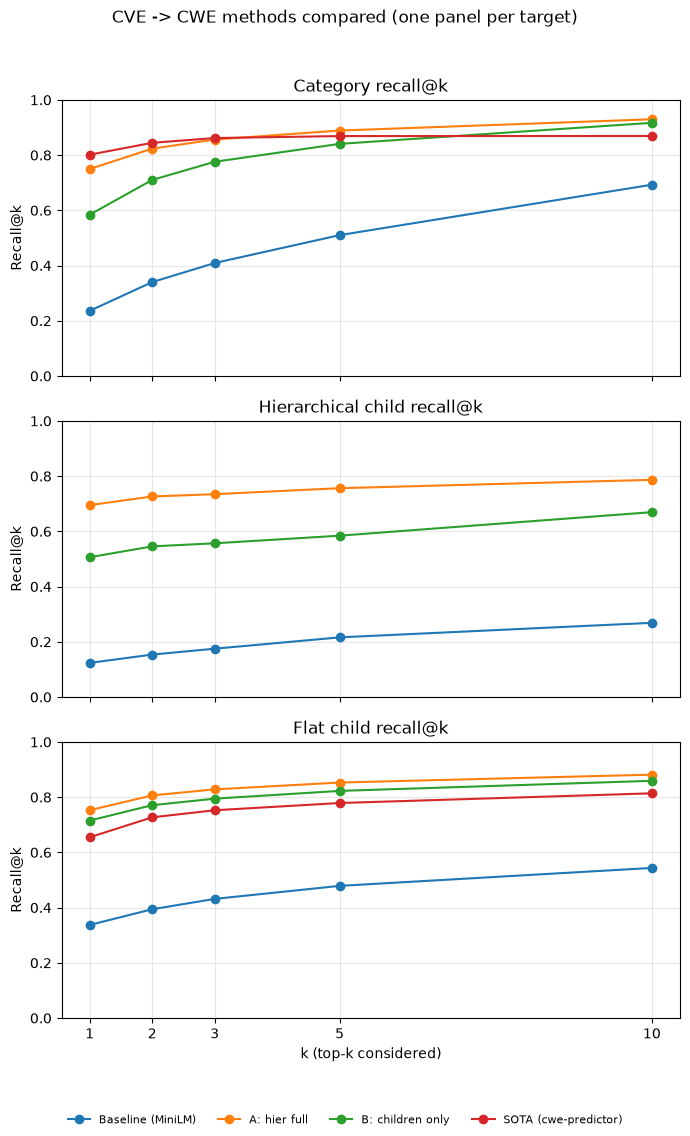

In [21]:
METRIC_ORDER = ["category", "child (hierarchical)", "child (flat)"]
METRIC_TITLES = {
    "category": "Category recall@k",
    "child (hierarchical)": "Hierarchical child recall@k",
    "child (flat)": "Flat child recall@k",
}

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(7, 11), sharex=True, sharey=True
)

for ax, metric in zip(axes, METRIC_ORDER):
    sub = results_df[results_df["metric"] == metric]
    for method in METHOD_ORDER:
        g = sub[sub["method"] == method].sort_values("k")
        if g.empty:
            continue
        ax.plot(g["k"], g["recall"], marker="o", label=method)
    ax.set_title(METRIC_TITLES[metric])
    ax.set_xticks(KS)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Recall@k")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("k (top-k considered)")  # only the bottom panel needs the x label

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=max(len(labels), 1), fontsize=8, frameon=False)
fig.suptitle("CVE -> CWE methods compared (one panel per target)", y=1.02)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Grouped bar chart at one k

If the curves are still busy, this single-`k` view is the most direct "who wins" summary.

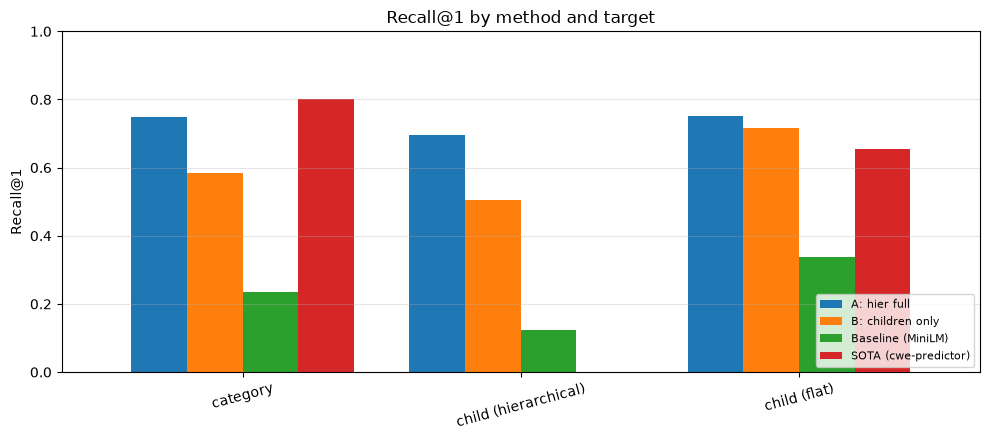

In [16]:
BAR_K = 1
bar = (
    results_df[results_df["k"] == BAR_K]
    .pivot(index="metric", columns="method", values="recall")
    .reindex(METRIC_ORDER)
)

ax = bar.plot(kind="bar", figsize=(10, 4.5), width=0.8)
ax.set_ylabel(f"Recall@{BAR_K}")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.set_title(f"Recall@{BAR_K} by method and target")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
PAPER_KS = [1, 3, 5]  # <- edit to the k's you want

tbl = results_df[results_df["k"].isin(PAPER_KS)].copy()
tbl["metric"] = pd.Categorical(tbl["metric"], categories=METRIC_ORDER, ordered=True)
tbl["method"] = pd.Categorical(tbl["method"], categories=METHOD_ORDER, ordered=True)

table = (
    tbl.pivot_table(index="method", columns=["metric", "k"], values="recall", observed=True)
       .sort_index(axis=1)
)
table.index.name = None
table.columns.names = [None, None]

# Show in notebook
display(table.style.format("{:.3f}").highlight_max(axis=0, props="font-weight:bold"))

# LaTeX for the paper
latex = (
    table.style
         .format("{:.3f}")
         .highlight_max(axis=0, props="textbf:--rwrap;")
         .to_latex(
             column_format="l" + "c" * table.shape[1],
             hrules=True,
             multicol_align="c",
             caption="CVE$\\rightarrow$CWE recall@k for each method.",
             label="tab:recall",
         )
)
print(latex)

\begin{table}
\caption{CVE$\rightarrow$CWE recall@k for each method.}
\label{tab:recall}
\begin{tabular}{lccccccccc}
\toprule
 & \multicolumn{3}{c}{category} & \multicolumn{3}{c}{child (hierarchical)} & \multicolumn{3}{c}{child (flat)} \\
 & 1 & 3 & 5 & 1 & 3 & 5 & 1 & 3 & 5 \\
\midrule
Baseline (MiniLM) & 0.236 & 0.409 & 0.510 & 0.124 & 0.175 & 0.216 & 0.337 & 0.432 & 0.479 \\
A: hier full & 0.750 & 0.856 & \textbf{0.889} & \textbf{0.695} & \textbf{0.735} & \textbf{0.756} & \textbf{0.753} & \textbf{0.828} & \textbf{0.853} \\
B: children only & 0.584 & 0.776 & 0.841 & 0.506 & 0.557 & 0.584 & 0.715 & 0.795 & 0.823 \\
SOTA (cwe-predictor) & \textbf{0.802} & \textbf{0.862} & 0.869 & nan & nan & nan & 0.655 & 0.753 & 0.779 \\
\bottomrule
\end{tabular}
\end{table}



In [22]:
import numpy as np

PAPER_KS = [1, 3, 5]

tbl = results_df[results_df["k"].isin(PAPER_KS)].copy()
tbl["metric"] = pd.Categorical(tbl["metric"], categories=METRIC_ORDER, ordered=True)
tbl["method"] = pd.Categorical(tbl["method"], categories=METHOD_ORDER, ordered=True)

table = (
    tbl.pivot_table(index=["metric", "method"], columns="k", values="recall", observed=True)
       .sort_index()
)
table.index.names = [None, None]
table.columns.name = None
table.columns = [f"@{k}" for k in table.columns]

# Short row-group labels (edit to taste)
SHORT = {
    "category": "Category",
    "child (hierarchical)": "Child (hier.)",
    "child (flat)": "Child (flat)",
}
table = table.rename(index=SHORT, level=0)

def mark_max(col, prop):
    """Flag the best method within each metric group."""
    is_max = col.groupby(level=0, observed=True).transform("max") == col
    return np.where(is_max, prop, "")

# Notebook view
display(table.style.format("{:.3f}").apply(mark_max, prop="font-weight:bold", axis=0))

# LaTeX for the paper
latex = (
    table.style
         .format("{:.3f}")
         .apply(mark_max, prop="textbf:--rwrap;", axis=0)
         .to_latex(
             column_format="llccc",
             hrules=True,
             clines="skip-last;data",
             multirow_align="c",
             position_float="centering",
             caption="CVE$\\rightarrow$CWE recall@$k$ for each method.",
             label="tab:recall",
         )
)
print(latex)

\begin{table}
\centering
\caption{CVE$\rightarrow$CWE recall@$k$ for each method.}
\label{tab:recall}
\begin{tabular}{llccc}
\toprule
 &  & @1 & @3 & @5 \\
\midrule
\multirow[c]{4}{*}{Category} & Baseline (MiniLM) & 0.236 & 0.409 & 0.510 \\
 & A: hier full & 0.750 & 0.856 & \textbf{0.889} \\
 & B: children only & 0.584 & 0.776 & 0.841 \\
 & SOTA (cwe-predictor) & \textbf{0.802} & \textbf{0.862} & 0.869 \\
\cline{1-5}
\multirow[c]{3}{*}{Child (hier.)} & Baseline (MiniLM) & 0.124 & 0.175 & 0.216 \\
 & A: hier full & \textbf{0.695} & \textbf{0.735} & \textbf{0.756} \\
 & B: children only & 0.506 & 0.557 & 0.584 \\
\cline{1-5}
\multirow[c]{4}{*}{Child (flat)} & Baseline (MiniLM) & 0.337 & 0.432 & 0.479 \\
 & A: hier full & \textbf{0.753} & \textbf{0.828} & \textbf{0.853} \\
 & B: children only & 0.715 & 0.795 & 0.823 \\
 & SOTA (cwe-predictor) & 0.655 & 0.753 & 0.779 \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



## Reading the results

- **Category** and **hierarchical child** columns show the benefit of the two-stage pipeline in
  `merged_A_hier_full`: the category stage is a strong ceiling for the child stage.
- **Flat child** compares the embedding models head-to-head with SOTA on the exact same task.
- The per-target panels and the table let you see, for example, whether `A: hier full` beats
  `B: children only` on both the category target and the flat-child target without untangling
  overlapping lines.

`comparison_results.csv` is written next to the notebook for reuse or plotting elsewhere.